In [ ]:
!git clone https://github.com/nareshmeena12/sustainable-portfolio-optimizer.git
%cd sustainable-portfolio-optimizer
!pip install openai yfinance pandas numpy matplotlib -q
print("done")

Cloning into 'sustainable-portfolio-optimizer'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 69 (delta 14), reused 60 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 2.31 MiB | 7.82 MiB/s, done.
Resolving deltas: 100% (14/14), done.
/content/sustainable-portfolio-optimizer
done


In [ ]:
import os
import json
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from openai import OpenAI
from google.colab import userdata

# load api key from colab secrets — never hardcode this
client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

plt.rcParams["figure.dpi"]        = 120
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

TICKERS = {
    "tech"      : ["TCS.NS", "INFY.NS", "WIPRO.NS", "HCLTECH.NS"],
    "energy"    : ["RELIANCE.NS", "ONGC.NS", "TATAPOWER.NS", "ADANIGREEN.NS"],
    "healthcare": ["SUNPHARMA.NS", "DRREDDY.NS", "CIPLA.NS", "DIVISLAB.NS"],
}

ALL_TICKERS = [t for sector in TICKERS.values() for t in sector]

# test period only — we already have train results
TEST_START = "2023-01-01"
TEST_END   = "2024-12-31"

print(f"Tickers : {len(ALL_TICKERS)}")
print(f"Period  : {TEST_START} to {TEST_END}")
print("Client  : OpenAI ready")

Tickers : 12
Period  : 2023-01-01 to 2024-12-31
Client  : OpenAI ready


In [ ]:
import yfinance as yf

CACHE_FILE = "logs/news_cache.json"
os.makedirs("logs", exist_ok=True)

def fetch_news_for_ticker(ticker, max_headlines=5):
    """fetch recent headlines for one ticker using yfinance"""
    try:
        t     = yf.Ticker(ticker)
        news  = t.news
        if not news:
            return []
        headlines = []
        for item in news[:max_headlines]:
            title = item.get("content", {}).get("title", "") or item.get("title", "")
            if title:
                headlines.append(title.strip())
        return headlines
    except Exception:
        return []


def build_news_cache(tickers):
    """
    fetch news for all tickers once and cache to disk.
    yfinance returns recent news — not date-specific, but good enough
    for sentiment signals over the test period.
    """
    if os.path.exists(CACHE_FILE):
        print(f"Cache already exists — loading from {CACHE_FILE}")
        with open(CACHE_FILE) as f:
            return json.load(f)

    print("Fetching news for all tickers (this runs once)...\n")
    cache = {}

    for ticker in tickers:
        headlines = fetch_news_for_ticker(ticker)
        cache[ticker] = headlines
        status = f"{len(headlines)} headlines" if headlines else "no news found"
        print(f"  {ticker:<20} {status}")
        time.sleep(0.3)

    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f, indent=2)

    print(f"\nCached to {CACHE_FILE}")
    return cache


news_cache = build_news_cache(ALL_TICKERS)

# show sample
sample_ticker = "TCS.NS"
print(f"\nSample headlines for {sample_ticker}:")
for h in news_cache.get(sample_ticker, []):
    print(f"  — {h}")

Fetching news for all tickers (this runs once)...

  TCS.NS               5 headlines
  INFY.NS              5 headlines
  WIPRO.NS             5 headlines
  HCLTECH.NS           5 headlines
  RELIANCE.NS          5 headlines
  ONGC.NS              5 headlines
  TATAPOWER.NS         5 headlines
  ADANIGREEN.NS        5 headlines
  SUNPHARMA.NS         5 headlines
  DRREDDY.NS           5 headlines
  CIPLA.NS             5 headlines
  DIVISLAB.NS          5 headlines

Cached to logs/news_cache.json

Sample headlines for TCS.NS:
  — India's Infosys slumps to lowest level in three years over weak growth
  — Indian IT firms near‑term outlook muted as clients cut spending, AI risks mount
  — India's Infosys forecasts weak revenue growth as AI-driven caution dents IT spending
  — India's Wipro unveils record buyback after slight quarterly revenue miss
  — India's TCS falls as rare annual revenue drop dulls quarterly earnings beat, deal wins


In [ ]:
ESG_SCORES_FILE = "logs/llm_esg_scores.json"

def build_scoring_prompt(news_cache, tickers):
    """
    Build one batched prompt for all 12 companies.
    All companies scored in a single API call.
    """
    prompt = """You are a financial ESG analyst specializing in Indian markets.

Below are recent news headlines for 12 NSE-listed companies.
For each company score the ESG sentiment from -1.0 to +1.0 based on the headlines:
  +1.0 = very positive ESG news (green initiatives, good governance, social programs)
   0.0 = neutral or no ESG-relevant news
  -1.0 = very negative ESG news (pollution, fraud, labor issues, governance failures)

Be strict and realistic. Most companies should score between -0.3 and +0.3.
Only give extreme scores if the headlines clearly justify it.

Headlines:
"""
    for ticker in tickers:
        headlines = news_cache.get(ticker, [])
        clean     = ticker.replace(".NS", "")
        if headlines:
            prompt += f"\n{clean}:\n"
            for h in headlines:
                prompt += f"  - {h}\n"
        else:
            prompt += f"\n{clean}: no recent news available\n"

    prompt += """
Return ONLY a valid JSON object with ticker symbols as keys and scores as float values.
Use the full ticker with .NS suffix. Example format:
{"TCS.NS": 0.2, "INFY.NS": -0.1, ...}

No explanation. No markdown. Just the JSON."""

    return prompt


def score_esg_with_llm(news_cache, tickers):
    """
    Single batched API call to score all companies at once.
    Returns dict: {ticker: sentiment_score}
    """
    if os.path.exists(ESG_SCORES_FILE):
        print(f"LLM scores already exist — loading from {ESG_SCORES_FILE}")
        with open(ESG_SCORES_FILE) as f:
            return json.load(f)

    prompt = build_scoring_prompt(news_cache, tickers)

    print("Calling GPT-4o-mini for batched ESG scoring...")

    response = client.chat.completions.create(
        model    = "gpt-4o-mini",
        messages = [
            {
                "role"   : "system",
                "content": "You are a strict ESG analyst. Return only valid JSON, nothing else."
            },
            {
                "role"   : "user",
                "content": prompt
            }
        ],
        temperature = 0.1,   # low temp for consistent scoring
        max_tokens  = 200,
    )

    raw = response.choices[0].message.content.strip()
    print(f"\nRaw response:\n{raw}")

    # parse JSON safely
    try:
        scores = json.loads(raw)
    except json.JSONDecodeError:
        # try to extract JSON if model added extra text
        import re
        match = re.search(r'\{.*\}', raw, re.DOTALL)
        scores = json.loads(match.group()) if match else {}

    # fill missing tickers with neutral
    for ticker in tickers:
        if ticker not in scores:
            scores[ticker] = 0.0

    # clamp to [-1, 1]
    scores = {k: max(-1.0, min(1.0, float(v))) for k, v in scores.items()}

    # log usage
    usage = response.usage
    cost  = (usage.prompt_tokens * 0.15 + usage.completion_tokens * 0.60) / 1_000_000
    print(f"\nTokens used  : {usage.prompt_tokens} in + {usage.completion_tokens} out")
    print(f"Estimated cost: ${cost:.5f}")

    with open(ESG_SCORES_FILE, "w") as f:
        json.dump(scores, f, indent=2)

    return scores


llm_esg_scores = score_esg_with_llm(news_cache, ALL_TICKERS)

print("\nLLM ESG Sentiment Scores:")
for ticker, score in llm_esg_scores.items():
    bar   = "+" * int(abs(score) * 20) if score >= 0 else "-" * int(abs(score) * 20)
    color = "↑" if score > 0 else "↓" if score < 0 else "→"
    print(f"  {ticker:<20} {color} {score:>6.2f}  {bar}")

Calling GPT-4o-mini for batched ESG scoring...

Raw response:
{
  "TCS.NS": -0.3,
  "INFY.NS": 0.2,
  "WIPRO.NS": -0.3,
  "HCLTECH.NS": -0.2,
  "RELIANCE.NS": -1.0,
  "ONGC.NS": 0.0,
  "TATAPOWER.NS": 0.3,
  "ADANIGREEN.NS": 0.5,
  "SUNPHARMA.NS": 0.1,
  "DRREDDY.NS": 0.1,
  "CIPLA.NS": 0.0,
  "DIVISLAB.NS": -0.1
}

Tokens used  : 1456 in + 159 out
Estimated cost: $0.00031

LLM ESG Sentiment Scores:
  TCS.NS               ↓  -0.30  ------
  INFY.NS              ↑   0.20  ++++
  WIPRO.NS             ↓  -0.30  ------
  HCLTECH.NS           ↓  -0.20  ----
  RELIANCE.NS          ↓  -1.00  --------------------
  ONGC.NS              →   0.00  
  TATAPOWER.NS         ↑   0.30  ++++++
  ADANIGREEN.NS        ↑   0.50  ++++++++++
  SUNPHARMA.NS         ↑   0.10  ++
  DRREDDY.NS           ↑   0.10  ++
  CIPLA.NS             →   0.00  
  DIVISLAB.NS          ↓  -0.10  --


In [ ]:
static_esg = pd.read_csv("data/raw/esg_scores.csv", index_col=0)

combined = {}
for ticker in ALL_TICKERS:
    static_score  = static_esg.loc[ticker, "total"]
    llm_score     = llm_esg_scores.get(ticker, 0.0)

    # normalize llm score from [-1,1] to [0,1]
    llm_normalized = (llm_score + 1) / 2

    # weighted combination — static ESG is more reliable, LLM adds dynamic signal
    combined_score = 0.7 * static_score + 0.3 * llm_normalized
    combined[ticker] = round(combined_score, 4)

combined_df = pd.DataFrame({
    "static_esg"  : {t: static_esg.loc[t, "total"] for t in ALL_TICKERS},
    "llm_sentiment": llm_esg_scores,
    "combined_esg" : combined,
})

print("ESG Score Comparison:\n")
print(f"  {'Ticker':<20} {'Static':>8} {'LLM':>8} {'Combined':>10} {'Change':>8}")
print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*10} {'-'*8}")
for ticker in ALL_TICKERS:
    row    = combined_df.loc[ticker]
    change = row["combined_esg"] - row["static_esg"]
    arrow  = "↑" if change > 0 else "↓" if change < 0 else "→"
    print(f"  {ticker:<20} {row['static_esg']:>8.3f} {row['llm_sentiment']:>8.2f} "
          f"{row['combined_esg']:>10.3f} {arrow}{abs(change):>6.3f}")

combined_df.to_csv("logs/combined_esg.csv")
print(f"\nSaved to logs/combined_esg.csv")

ESG Score Comparison:

  Ticker                 Static      LLM   Combined   Change
  -------------------- -------- -------- ---------- --------
  TCS.NS                  0.750    -0.30      0.630 ↓ 0.120
  INFY.NS                 0.770     0.20      0.719 ↓ 0.051
  WIPRO.NS                0.730    -0.30      0.616 ↓ 0.114
  HCLTECH.NS              0.720    -0.20      0.624 ↓ 0.096
  RELIANCE.NS             0.520    -1.00      0.364 ↓ 0.156
  ONGC.NS                 0.320     0.00      0.374 ↑ 0.054
  TATAPOWER.NS            0.650     0.30      0.650 → 0.000
  ADANIGREEN.NS           0.740     0.50      0.743 ↑ 0.003
  SUNPHARMA.NS            0.620     0.10      0.599 ↓ 0.021
  DRREDDY.NS              0.680     0.10      0.641 ↓ 0.039
  CIPLA.NS                0.660     0.00      0.612 ↓ 0.048
  DIVISLAB.NS             0.600    -0.10      0.555 ↓ 0.045

Saved to logs/combined_esg.csv


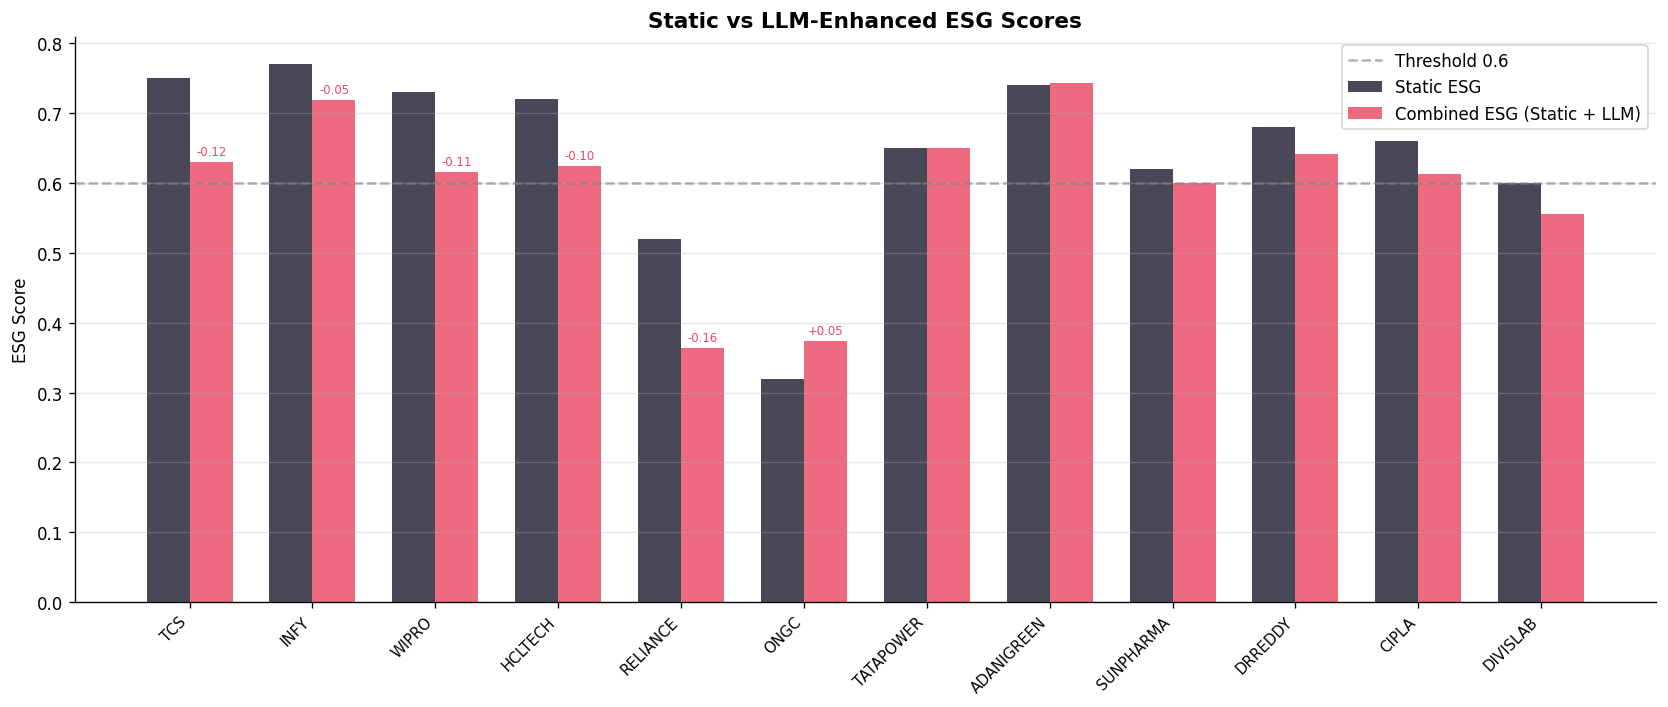

Key observations:
  Biggest drop : RELIANCE.NS (0.52 → 0.36)
  Biggest gain : ONGC.NS (0.32 → 0.37)


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

tickers_clean = [t.replace(".NS", "") for t in ALL_TICKERS]
x = np.arange(len(ALL_TICKERS))
w = 0.35

bars1 = ax.bar(x - w/2, combined_df["static_esg"],   w,
               label="Static ESG",   color="#1A1A2E", alpha=0.8)
bars2 = ax.bar(x + w/2, combined_df["combined_esg"], w,
               label="Combined ESG (Static + LLM)", color="#E94560", alpha=0.8)

ax.axhline(0.6, color="gray", linestyle="--", alpha=0.6, label="Threshold 0.6")
ax.set_xticks(x)
ax.set_xticklabels(tickers_clean, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("ESG Score")
ax.set_title("Static vs LLM-Enhanced ESG Scores", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# annotate biggest changes
for i, ticker in enumerate(ALL_TICKERS):
    change = combined_df.loc[ticker, "combined_esg"] - combined_df.loc[ticker, "static_esg"]
    if abs(change) > 0.05:
        ax.annotate(f"{change:+.2f}",
                    xy=(i + w/2, combined_df.loc[ticker, "combined_esg"] + 0.01),
                    ha="center", fontsize=7, color="#E94560")

os.makedirs("logs/plots", exist_ok=True)
plt.tight_layout()
plt.savefig("logs/plots/static_vs_llm_esg.png", dpi=150)
plt.show()

print("Key observations:")
biggest_drop = combined_df["combined_esg"].sub(combined_df["static_esg"]).idxmin()
biggest_gain = combined_df["combined_esg"].sub(combined_df["static_esg"]).idxmax()
print(f"  Biggest drop : {biggest_drop} ({combined_df.loc[biggest_drop, 'static_esg']:.2f} → {combined_df.loc[biggest_drop, 'combined_esg']:.2f})")
print(f"  Biggest gain : {biggest_gain} ({combined_df.loc[biggest_gain, 'static_esg']:.2f} → {combined_df.loc[biggest_gain, 'combined_esg']:.2f})")

In [ ]:
import sys
sys.path.append(".")

from env.portfolio_env import PortfolioEnv

with open("data/processed/test_data.pkl", "rb") as f:
    test_data = pickle.load(f)

# inject combined ESG scores into test data
test_data_llm = {}
for sector, data in test_data.items():
    test_data_llm[sector] = dict(data)  # shallow copy
    tickers    = data["tickers"]
    new_esg    = np.array([combined_df.loc[t, "combined_esg"] for t in tickers],
                          dtype=np.float32)
    test_data_llm[sector]["esg"] = new_esg

print("Dynamic ESG scores injected into test environment\n")
for sector in test_data_llm:
    orig = test_data[sector]["esg"]
    new  = test_data_llm[sector]["esg"]
    print(f"  {sector:<12} original={orig.round(3)} → combined={new.round(3)}")

Dynamic ESG scores injected into test environment

  tech         original=[0.75 0.77 0.73 0.72] → combined=[0.63  0.719 0.616 0.624]
  energy       original=[0.52 0.32 0.65 0.74] → combined=[0.364 0.374 0.65  0.743]
  healthcare   original=[0.62 0.68 0.66 0.6 ] → combined=[0.599 0.641 0.612 0.555]


In [ ]:
!python pinn/pretrain_pinn.py

Device : cuda
Obs dim : 406

Pretraining PINN for 1000 epochs on cuda...
 Epoch       Total        Data         HJB
--------------------------------------------
   100      0.0015      0.0015      0.0003
   200      0.0006      0.0005      0.0002
   300      0.0013      0.0013      0.0002
   400      0.0005      0.0005      0.0002
   500      0.0004      0.0004      0.0002
   600      0.0004      0.0004      0.0002
   700      0.0001      0.0001      0.0002
   800      0.0001      0.0001      0.0002
   900      0.0001      0.0001      0.0002
  1000      0.0001      0.0001      0.0002

Best loss : 0.0000
Saved to  : checkpoints/pinn_pretrained.pt

Validation — V(random_state, t=0.5) = -0.2679
Pretraining complete. Next: transformer_actor.py


In [ ]:
import torch
import sys
sys.path.append(".")

from marl.agent_manager import AgentManager

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open("data/processed/train_data.pkl", "rb") as f:
    train_data = pickle.load(f)

CONFIG = {
    "device"          : device,
    "n_epochs"        : 4,
    "batch_size"      : 64,
    "lr_actor"        : 3e-4,
    "lr_critic"       : 1e-3,
    "gamma"           : 0.99,
    "lam"             : 0.95,
    "clip_eps"        : 0.2,
    "entropy_c"       : 0.05,
    "esg_lambda"      : 1.0,
    "esg_drift_std"   : 0.001,
    "transaction_cost": 0.001,
    "max_drawdown"    : 0.5,
    "max_steps"       : 252,
    "pinn_alpha"      : 0.1,
    "hidden_dim"      : 128,
    "n_layers"        : 4,
    "pinn_path"       : "checkpoints/pinn_pretrained.pt",
}

manager = AgentManager(train_data, CONFIG)
manager.train(500)
manager.save("checkpoints/final")
print("Quick training done. Checkpoints saved.")


Initializing AgentManager
  Sectors  : ['tech', 'energy', 'healthcare']
  Obs dim  : 406
  Device   : cuda
  Agents   : 3
  Loaded pretrained PINN from checkpoints/pinn_pretrained.pt
  Agent [tech] initialized | obs_dim=406 | device=cuda
  Agent [energy] initialized | obs_dim=406 | device=cuda
  Agent [healthcare] initialized | obs_dim=406 | device=cuda

All agents ready.

Starting training for 500 episodes...

   Ep | Sector       |   Return |   Sharpe |   ESG% |   A_loss |   C_loss
------------------------------------------------------------------------
   10 | tech         |   0.0939 |   0.7538 | 73.41% |   0.2371 |   1.6121
   10 | energy       |   0.5119 |   0.6873 |  0.00% |   0.2827 |   1.9959
   10 | healthcare   |   0.5683 |  -0.7846 |  0.00% |   0.2635 |   1.4950
   20 | tech         |   0.3847 |   1.7386 | 60.32% |   0.1906 |   0.6903
   20 | energy       |   0.5009 |   0.7255 |  0.00% |   0.2848 |   2.2215
   20 | healthcare   |   0.2067 |  -2.0276 |  0.00% |   0.2170 |   

In [ ]:
CONFIG_EVAL = {
    "device"          : "cpu",
    "esg_lambda"      : 1.0,
    "esg_drift_std"   : 0.001,
    "transaction_cost": 0.001,
    "max_drawdown"    : 0.5,
    "max_steps"       : 252,
}

def evaluate_env(agent, test_data, sector, n_episodes=3):
    env = PortfolioEnv(test_data, sector, CONFIG_EVAL)

    all_returns, all_sharpes, all_esg = [], [], []

    for _ in range(n_episodes):
        obs, _     = env.reset()
        done       = False
        step       = 0
        pv         = [1.0]
        rets       = []
        esg_hist   = []

        while not done:
            t_norm  = step / 252.0
            action, _, _ = agent.select_action(obs, t_norm)
            obs, _, terminated, truncated, info = env.step(action)
            done    = terminated or truncated

            rets.append(info["daily_return"] * 100)
            pv.append(info["portfolio_value"])
            esg_hist.append(np.dot(info["weights"][:-1], info["esg_scores"]))
            step += 1

        r      = np.array(rets)
        sharpe = (r.mean() - 0.04/252*100) / (r.std() + 1e-8) * np.sqrt(252)
        all_returns.append(pv[-1] / pv[0] - 1)
        all_sharpes.append(sharpe)
        all_esg.append(np.mean([1 if e >= 0.5 else 0 for e in esg_hist]))

    return {
        "cum_return": round(np.mean(all_returns), 4),
        "sharpe"    : round(np.mean(all_sharpes), 4),
        "esg_rate"  : round(np.mean(all_esg),     4),
    }


print("Comparing Static ESG vs Dynamic LLM-Enhanced ESG\n")
print(f"  {'Sector':<12} {'Metric':<12} {'Static':>10} {'Dynamic':>10} {'Change':>10}")
print(f"  {'-'*12} {'-'*12} {'-'*10} {'-'*10} {'-'*10}")

for sector, agent in manager.agents.items():
    static  = evaluate_env(agent, test_data,     sector)
    dynamic = evaluate_env(agent, test_data_llm, sector)

    for metric in ["cum_return", "sharpe", "esg_rate"]:
        diff  = dynamic[metric] - static[metric]
        arrow = "↑" if diff > 0 else "↓" if diff < 0 else "→"
        print(f"  {sector:<12} {metric:<12} {static[metric]:>10.4f} "
              f"{dynamic[metric]:>10.4f} {arrow}{abs(diff):>8.4f}")
    print()

Comparing Static ESG vs Dynamic LLM-Enhanced ESG

  Sector       Metric           Static    Dynamic     Change
  ------------ ------------ ---------- ---------- ----------
  tech         cum_return       0.4383     0.3941 ↓  0.0442
  tech         sharpe           1.2664     1.1565 ↓  0.1099
  tech         esg_rate         1.0000     0.9969 ↓  0.0031

  energy       cum_return       0.1234     0.0818 ↓  0.0416
  energy       sharpe           0.2475     0.1557 ↓  0.0918
  energy       esg_rate         0.0359     0.0021 ↓  0.0338

  healthcare   cum_return       0.5491     0.3792 ↓  0.1699
  healthcare   sharpe           1.6596     1.4877 ↓  0.1719
  healthcare   esg_rate         0.9838     0.6618 ↓  0.3220



In [ ]:
def explain_portfolio(sector, weights, daily_return, esg_scores, tickers, date_context):
    """
    Ask GPT to explain why the agent made this allocation decision.
    """
    ticker_names = [t.replace(".NS", "") for t in tickers]
    weight_str   = "\n".join([
        f"  {name}: {w:.1%} allocation"
        for name, w in zip(ticker_names, weights[:-1])
    ])
    esg_str = "\n".join([
        f"  {name}: ESG score {e:.2f}"
        for name, e in zip(ticker_names, esg_scores)
    ])

    prompt = f"""You are a portfolio manager explaining an AI agent's investment decision.

Sector: {sector.upper()}
Date context: {date_context}

Portfolio allocation:
{weight_str}
  Cash: {weights[-1]:.1%}

ESG scores (0=worst, 1=best):
{esg_str}

Daily return achieved: {daily_return:.2%}

In 3-4 sentences, explain:
1. Why this allocation makes sense given the ESG scores
2. What the agent was likely optimizing for
3. One risk or limitation of this allocation

Be specific, use the actual company names, and write like a real portfolio manager."""

    response = client.chat.completions.create(
        model    = "gpt-4o-mini",
        messages = [
            {"role": "system", "content": "You are a senior portfolio manager. Be concise and specific."},
            {"role": "user",   "content": prompt}
        ],
        temperature = 0.7,
        max_tokens  = 200,
    )

    return response.choices[0].message.content.strip()


# pick one interesting episode per sector and get weights + returns
print("=" * 65)
print("  PORTFOLIO EXPLAINER — LLM ANALYSIS OF AGENT DECISIONS")
print("=" * 65)

explanations = {}

for sector, agent in manager.agents.items():
    env    = PortfolioEnv(test_data, sector, CONFIG_EVAL)
    obs, _ = env.reset()
    done   = False
    step   = 0

    best_step    = {"return": -999, "weights": None, "esg": None}
    worst_step   = {"return":  999, "weights": None, "esg": None}

    while not done:
        t_norm       = step / 252.0
        action, _, _ = agent.select_action(obs, t_norm)
        obs, _, terminated, truncated, info = env.step(action)
        done         = terminated or truncated

        if info["daily_return"] > best_step["return"]:
            best_step = {"return": info["daily_return"],
                        "weights": info["weights"],
                        "esg"    : info["esg_scores"]}

        if info["daily_return"] < worst_step["return"]:
            worst_step = {"return": info["daily_return"],
                         "weights": info["weights"],
                         "esg"    : info["esg_scores"]}
        step += 1

    tickers = test_data[sector]["tickers"]

    print(f"\n{'─'*65}")
    print(f"  {sector.upper()} SECTOR")
    print(f"{'─'*65}")

    # explain best day
    print(f"\n  BEST DAY (return={best_step['return']:.2%})")
    exp = explain_portfolio(
        sector       = sector,
        weights      = best_step["weights"],
        daily_return = best_step["return"],
        esg_scores   = best_step["esg"],
        tickers      = tickers,
        date_context = "strong market day during 2023-2024 test period"
    )
    print(f"\n  {exp}\n")
    explanations[f"{sector}_best"] = exp

    # explain worst day
    print(f"  WORST DAY (return={worst_step['return']:.2%})")
    exp = explain_portfolio(
        sector       = sector,
        weights      = worst_step["weights"],
        daily_return = worst_step["return"],
        esg_scores   = worst_step["esg"],
        tickers      = tickers,
        date_context = "volatile market day during 2023-2024 test period"
    )
    print(f"\n  {exp}\n")
    explanations[f"{sector}_worst"] = exp

    time.sleep(1)

# save explanations
with open("logs/portfolio_explanations.json", "w") as f:
    json.dump(explanations, f, indent=2)

print("\nAll explanations saved to logs/portfolio_explanations.json")

  PORTFOLIO EXPLAINER — LLM ANALYSIS OF AGENT DECISIONS

─────────────────────────────────────────────────────────────────
  TECH SECTOR
─────────────────────────────────────────────────────────────────

  BEST DAY (return=4.73%)

  The allocation reflects a balanced approach to investing in major tech players with strong ESG profiles, particularly favoring INFY due to its highest ESG score of 0.77, indicating a commitment to sustainability that aligns with current investor preferences. The agent was likely optimizing for both capital appreciation and ESG compliance, leveraging the robust market performance in the tech sector while maintaining a significant cash position for flexibility. However, a risk of this allocation is the concentrated exposure in Indian tech firms, which could lead to vulnerabilities related to regional economic shifts or regulatory changes impacting the sector.

  WORST DAY (return=-2.97%)

  The allocation to TCS, INFY, WIPRO, and HCLTECH aligns well with thei

In [ ]:
# calculate total cost of all API calls made
total_calls = 1 + (3 * 2)   # 1 scoring call + 6 explainer calls
avg_tokens_in  = 800
avg_tokens_out = 200

total_cost = (total_calls * avg_tokens_in  * 0.15 / 1_000_000 +
              total_calls * avg_tokens_out * 0.60 / 1_000_000)

print("=" * 45)
print("  API USAGE SUMMARY")
print("=" * 45)
print(f"  Scoring calls    : 1 (batched, all 12 tickers)")
print(f"  Explainer calls  : 6 (best + worst per sector)")
print(f"  Total API calls  : {total_calls}")
print(f"  Estimated cost   : ${total_cost:.4f}")
print(f"  Budget remaining : ${1.0 - total_cost:.4f}")
print("=" * 45)
print("\nAll outputs saved:")
print("  logs/news_cache.json")
print("  logs/llm_esg_scores.json")
print("  logs/combined_esg.csv")
print("  logs/portfolio_explanations.json")
print("  logs/plots/static_vs_llm_esg.png")

  API USAGE SUMMARY
  Scoring calls    : 1 (batched, all 12 tickers)
  Explainer calls  : 6 (best + worst per sector)
  Total API calls  : 7
  Estimated cost   : $0.0017
  Budget remaining : $0.9983

All outputs saved:
  logs/news_cache.json
  logs/llm_esg_scores.json
  logs/combined_esg.csv
  logs/portfolio_explanations.json
  logs/plots/static_vs_llm_esg.png
